# XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 1. LOAD DATASET (Menggunakan file yang sudah kita seleksi sebelumnya)
file_path = 'Dataset 5 ops + cems.xlsx'
df_final = pd.read_excel(file_path)

In [3]:
df_final

,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,963.383357,567.188810,15.563528,564.490362,89.382077,3.987283,257.473513,970.169352,124.009406,3.292357,...,172.99,2362.587163,329.71,310.26,4237.333333,2.22,565.60,5.37,155.64,89.855113
545,890.941643,567.664945,14.386963,565.543734,83.488775,1.646984,253.524998,895.883235,123.268547,3.498842,...,164.77,2421.984297,307.55,288.27,4237.333333,2.08,565.79,4.96,150.91,88.052730
546,882.807854,567.590635,14.158093,566.011767,102.147880,3.174934,252.915498,886.779790,124.640201,3.468605,...,169.38,2522.739965,303.77,284.50,4237.333333,2.05,565.84,4.84,149.64,85.018900
547,917.612111,567.520828,14.621877,566.072634,106.958025,6.522704,254.775243,915.165001,127.187321,3.320881,...,179.69,2584.543200,314.09,294.60,4237.333333,2.12,566.30,5.00,153.37,83.295960


In [4]:
# 2. SEPARASI FITUR DAN TARGET
# Menggunakan fitur yang sudah divalidasi memiliki VIF rendah dan MI tinggi
X = df_final.drop(columns=['Boiler Eff (%)'])
y = df_final['Boiler Eff (%)']

In [5]:
# 3. SPLIT DATA (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 4. SCALING DATA
# Sangat penting agar XGBoost lebih stabil secara numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# 5. INISIALISASI DAN TRAINING MODEL XGBOOST
# Parameter ini disesuaikan untuk regresi nilai kontinu (NPHR)
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,      # Ditingkatkan, namun dikombinasikan dengan early_stopping
    learning_rate=0.01,     # Diperkecil (0.01 - 0.03) agar pencarian nilai optimal lebih halus pada data kecil
    max_depth=3,            # Dikurangi (3-4). Data sedikit tidak butuh pohon yang terlalu dalam/kompleks
    subsample=0.7,          # Mengambil 70% data per iterasi untuk menambah variasi (stochasticity)
    colsample_bytree=0.7,   # Mengambil 70% fitur untuk mencegah dominasi fitur tertentu (seperti Coal Flow)
    gamma=0.1,              # Menambah regularisasi untuk mengontrol pemangkasan pohon
    reg_lambda=1,           # L2 regularization agar bobot model tidak terlalu besar
    objective='reg:squarederror',
    random_state=42
)

In [8]:
print("Sedang melatih model XGBoost...")
model_xgb.fit(X_train_scaled, y_train)

Sedang melatih model XGBoost...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = model_xgb.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

In [10]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.9789
Mean Abs Error  : 0.4187
Root MSE (RMSE) : 0.5918
MAPE: 0.49%
Max Error: 2.4405
Min Error: 0.0054


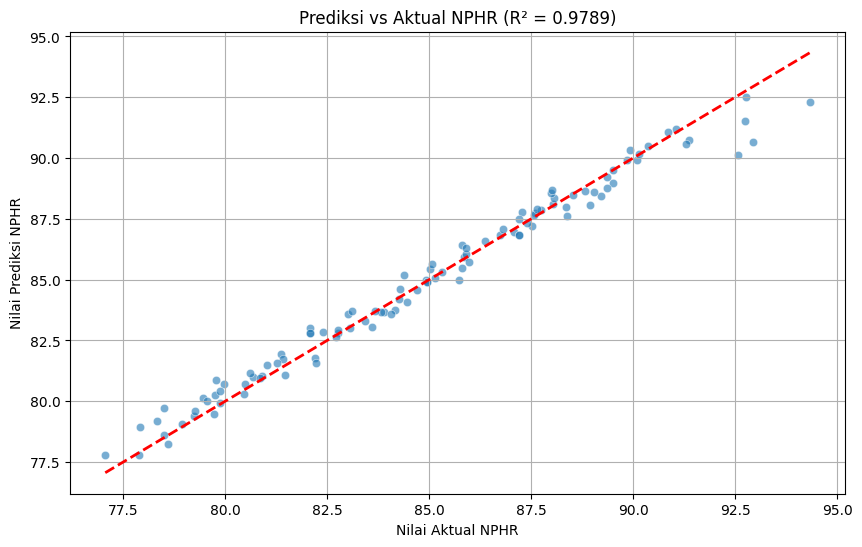

In [11]:
# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual NPHR')
plt.ylabel('Nilai Prediksi NPHR')
plt.title(f'Prediksi vs Aktual NPHR (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [12]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
     Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
195     92.946347        90.670692        2.275655              2.448353
79      79.873026        79.921394        0.048368              0.060556
479     87.525404        87.188187        0.337217              0.385280
109     88.952797        88.052818        0.899979              1.011749
473     82.775882        82.804031        0.028149              0.034007
490     86.736791        86.835968        0.099177              0.114343
84      80.690915        81.005043        0.314128              0.389298
368     89.218484        88.439072        0.779412              0.873600
132     90.370486        90.492325        0.121839              0.134821
364     79.446484        80.141869        0.695385              0.875287


In [13]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "a. #1 model prediction comparison dataset 5.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to a. #1 model prediction comparison dataset 5.xlsx!


<Figure size 1000x800 with 0 Axes>

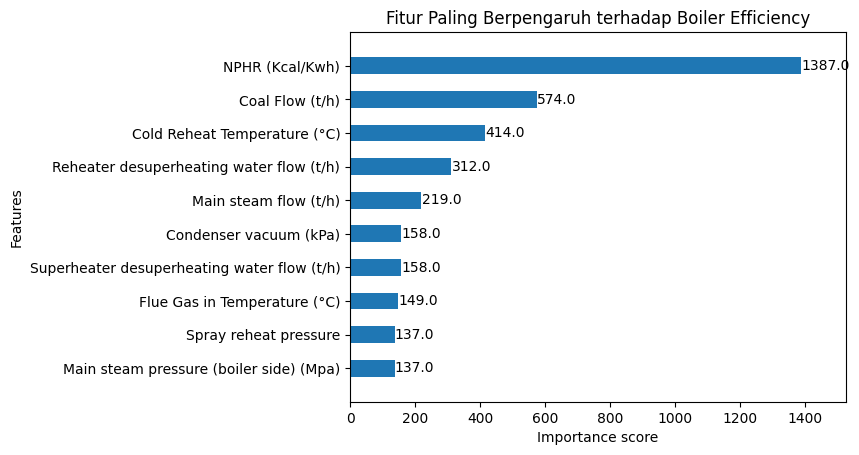

In [14]:
# 8. VISUALISASI FEATURE IMPORTANCE
# Pastikan model tahu nama fiturnya kembali jika sebelumnya menggunakan array hasil scaling
model_xgb.get_booster().feature_names = X.columns.tolist()

# Plotting
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, 
                   importance_type='weight', 
                   max_num_features=10, 
                   grid=False, 
                   height=0.5)
plt.title('Fitur Paling Berpengaruh terhadap Boiler Efficiency')
plt.show()